In [1]:
import cv2
import numpy as np

In [2]:
# mathmatical operation on images

image1 = cv2.imread('image1.jpg')
image2 = cv2.imread('image2.jpg')

# Using OpenCV addition (saturates at 255)
added_image = cv2.add(image1, image2)

# Using NumPy addition (wraps around if valuRe exceeds 255)
added_image_np = image1 + image2
cv2.imshow('window', added_image_np)
cv2.waitKey(0)

-1

In [3]:
# Using OpenCV subtraction
subtracted_image = cv2.subtract(image1, image2)

# Using NumPy subtraction
subtracted_image_np = image1 - image2
cv2.imshow('window', subtracted_image_np)
cv2.waitKey(0)

-1

In [8]:
alpha = 0.1  # Weight for the first image
beta = 0.8   # Weight for the second image
gamma = 0.9    # Scalar added to each sum

blended_image = cv2.addWeighted(image1, alpha, image2, beta, gamma)
cv2.imshow('window', blended_image)
#cv2.imshow('window', image1)

cv2.waitKey(0)

-1

In [21]:
# Multiply each pixel in the image by a scalar
multiplied_image = cv2.multiply(image1, np.array([1,1,1]))  # Multiplies intensity by 1.5
cv2.imshow('window', multiplied_image)
cv2.waitKey(0)

-1

In [27]:
# Create a mask : masking is a technique used to selectively process or operate on certain parts of an image while ignoring others
mask = cv2.imread('image1.jpg', 0)  # Grayscale mask
masked_image = cv2.bitwise_and(image1, image1, mask=mask)
# Perform bitwise OR
bitwise_or = cv2.bitwise_or(image1, image2)
# Perform bitwise NOT
bitwise_not = cv2.bitwise_not(image1)
cv2.imshow('window11', mask)
cv2.imshow('window1', masked_image)
cv2.imshow('window2', bitwise_or)
cv2.imshow('window3', bitwise_not)
cv2.waitKey(0)

-1

In [50]:
#masking example 2 : 
import cv2
import numpy as np

# Load an image
image = cv2.imread('image1.jpg')

# Create a binary mask with the same dimensions as the image
# Here, we create a circular mask in the center of the image
mask = np.zeros(image.shape[:2], dtype="uint8")
center_coordinates = (image.shape[1] // 2, image.shape[0] // 2)
radius = 100
cv2.circle(mask, center_coordinates, radius, 255, -1)  # White circle on black background

# Apply the mask to the image
masked_image = cv2.bitwise_and(image, image, mask=mask)

# Display the original and masked images
cv2.imshow('Original Image', image)
cv2.imshow('Masked Image', masked_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [29]:
#: Creating Simple Binary Images and Applying Bitwise Operations

# Create a black canvas
canvas1 = np.zeros((300, 300), dtype="uint8")
canvas2 = np.zeros((300, 300), dtype="uint8")

# Draw a white square on the first canvas
cv2.rectangle(canvas1, (50, 50), (250, 250), 255, -1)

# Draw a white circle on the second canvas
cv2.circle(canvas2, (150, 150), 100, 255, -1)

# Perform bitwise operations
bitwise_and = cv2.bitwise_and(canvas1, canvas2)
bitwise_or = cv2.bitwise_or(canvas1, canvas2)
bitwise_xor = cv2.bitwise_xor(canvas1, canvas2)
bitwise_not = cv2.bitwise_not(canvas1)
cv2.imshow('window1', bitwise_and)
cv2.imshow('window2', bitwise_or)
cv2.imshow('window3', bitwise_xor)
cv2.imshow('window4', bitwise_not)
cv2.waitKey(0)

-1

In [35]:
# Erosion : 
#Eroding an image is a morphological operation that reduces the boundaries of white regions (foreground) in a binary or grayscale image
import cv2
import numpy as np

# Load an image
image = cv2.imread('binary_image.png', 0)  # Load as grayscale

# Define a kernel (structuring element), typically a 3x3 matrix of ones
kernel = np.ones((3, 3), np.uint8)

# Perform erosion
eroded_image = cv2.erode(image, kernel, iterations=1)

# Display the result
cv2.imshow('Original Image', image)
cv2.imshow('Eroded Image', eroded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [36]:
# Blurring an image
import cv2
import numpy as np

# Load an image
image = cv2.imread('image1.jpg')

# Apply different blurs
average_blur = cv2.blur(image, (5, 5))
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)
median_blur = cv2.medianBlur(image, 5)
bilateral_blur = cv2.bilateralFilter(image, 9, 75, 75)

# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Averaging Blur', average_blur)
cv2.imshow('Gaussian Blur', gaussian_blur)
cv2.imshow('Median Blur', median_blur)
cv2.imshow('Bilateral Blur', bilateral_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [37]:
# border around the image


import cv2

# Load the image
image = cv2.imread('image1.jpg')

# Set the border size and color
top, bottom, left, right = 50, 50, 50, 50  # Border thickness for each side
border_color = (255, 0, 0)  # Blue border in BGR format

# Create a border
bordered_image = cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_CONSTANT, value=border_color)

# Display the original and bordered images
cv2.imshow('Original Image', image)
cv2.imshow('Bordered Image', bordered_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [38]:
# Rotation

# Get image dimensions
(h, w) = image.shape[:2]

# Define the rotation center, angle, and scale
center = (w // 2, h // 2)
angle = 45  # Rotate by 45 degrees
scale = 1.0  # Keep the same scale

# Get the rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

# Perform the rotation
rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))

cv2.imshow('Rotate1', rotation_matrix)
cv2.imshow('Rotate2', rotated_image)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [39]:
# Shifting an Image

# Define translation values
tx, ty = 50, 100  # Shift 50 pixels right and 100 pixels down

# Create the translation matrix
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])

# Apply the translation
shifted_image = cv2.warpAffine(image, translation_matrix, (w, h))
cv2.imshow('shifted_image', shifted_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [59]:
# Convert image to grayscale for edge detection
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detector
edges = cv2.Canny(gray_image, 100, 200)  # 100 and 200 are threshold values
cv2.imshow('gray_image', gray_image)
cv2.imshow('edges', edges)

cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.10.0) d:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0x46dff480::Set<1,-1,-1>,struct cv::impl::A0x46dff480::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


In [41]:
# Dilation: Dilation is a morphological operation in image processing that increases 
# the boundaries of the foreground objects in a binary or grayscale image
import cv2
import numpy as np

# Load a binary or grayscale image
image = cv2.imread('binary_image.png', 0)  # Load as grayscale

# Define a kernel (structuring element)
kernel = np.ones((5, 5), np.uint8)  # 5x5 matrix of ones

# Apply dilation
dilated_image = cv2.dilate(image, kernel, iterations=1)

# Display the result
cv2.imshow('Original Image', image)
cv2.imshow('Dilated Image', dilated_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


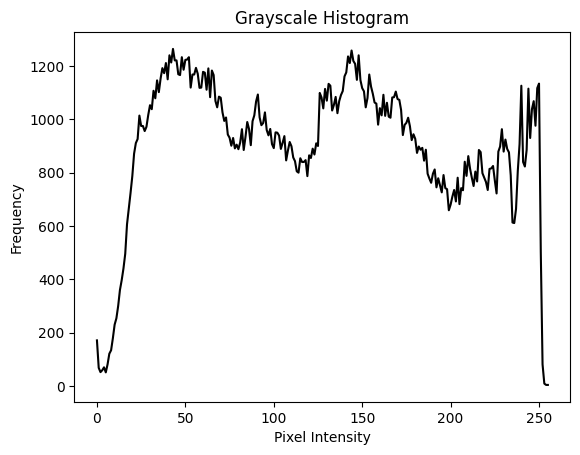

In [25]:
#histogram : Grayscale
import cv2
import matplotlib.pyplot as plt

# Load the image and convert it to grayscale
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate the histogram
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# Plot the histogram
plt.plot(hist, color='black')
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

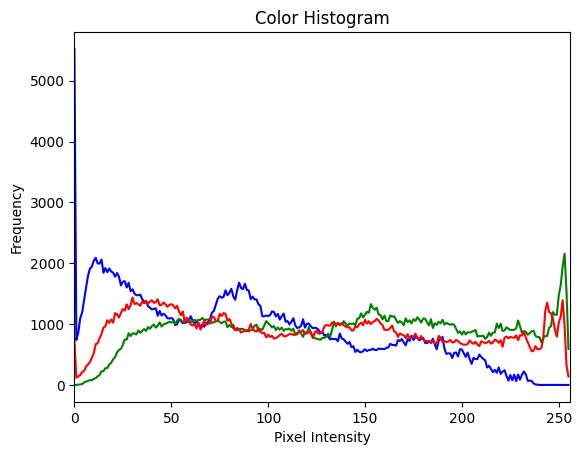

In [26]:
# Color histogram

# Load the color image
image = cv2.imread('image1.jpg')

# Calculate the histogram for each color channel
colors = ('b', 'g', 'r')
for i, color in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.xlim([0, 256])

# Plot
plt.title('Color Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()


In [42]:
# Histogram Equalization

import cv2

# Load the grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Histogram Equalization
equalized_image = cv2.equalizeHist(image)

# Display the original and equalized images
cv2.imshow('Original Image', image)
cv2.imshow('Equalized Image', equalized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



In [43]:
#Simple Threshold 
import cv2

# Load a grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Apply different types of thresholding
_, binary_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
_, binary_inv_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
_, trunc_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)
_, tozero_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)
_, tozero_inv_thresh = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)

# Display results
cv2.imshow('Original Image', image)
cv2.imshow('Binary Threshold', binary_thresh)
cv2.imshow('Binary Inverse Threshold', binary_inv_thresh)
cv2.imshow('Truncate Threshold', trunc_thresh)
cv2.imshow('To Zero Threshold', tozero_thresh)
cv2.imshow('To Zero Inverse Threshold', tozero_inv_thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [44]:
# Adaptive Threshold
import cv2

# Load the grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Adaptive Thresholding (Mean)
adaptive_mean = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Apply Adaptive Thresholding (Gaussian)
adaptive_gaussian = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Display the original and thresholded images
cv2.imshow('Original Image', image)
cv2.imshow('Adaptive Mean Threshold', adaptive_mean)
cv2.imshow('Adaptive Gaussian Threshold', adaptive_gaussian)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [45]:
# otsu thresholding
import cv2

# Load the grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Otsu's thresholding
_, otsu_thresholded_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the original and thresholded images
cv2.imshow('Original Image', image)
cv2.imshow('Otsu Thresholded Image', otsu_thresholded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [46]:
# Global Thresholding

import cv2

# Load the grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Choose a threshold value
threshold_value = 127

# Apply global thresholding
_, thresholded_image = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)

# Display the original and thresholded images
cv2.imshow('Original Image', image)
cv2.imshow('Thresholded Image', thresholded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [47]:
# Multilevel
import cv2
import numpy as np

# Load the grayscale image
image = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)

# Choose multiple threshold values
threshold_values = [85, 170]

# Apply multilevel thresholding
_, th1 = cv2.threshold(image, threshold_values[0], 255, cv2.THRESH_BINARY)
_, th2 = cv2.threshold(image, threshold_values[1], 255, cv2.THRESH_BINARY)

# Combine the results
combined_image = np.zeros_like(image)
combined_image[(image > threshold_values[1])] = 2
combined_image[(image > threshold_values[0]) & (image <= threshold_values[1])] = 1

# Display the thresholded images
cv2.imshow('Threshold Level 1', th1)
cv2.imshow('Threshold Level 2', th2)
cv2.imshow('Multilevel Thresholded Image', combined_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [49]:
# Filtering Color : Extractig red channel

import cv2

# Load the image
image = cv2.imread('image1.jpg')

# Split the image into R, G, B channels
(b, g, r) = cv2.split(image)

# Create a new image with only the red channel
red_image = cv2.merge([r, r, r])

# Display the original and red-filtered images
cv2.imshow('Original Image', image)
cv2.imshow('Red Channel Image', red_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [47]:
# Filtering based on color range
import cv2
import numpy as np

# Load the image
image = cv2.imread('image1.jpg')

# Convert the image from BGR to HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define the range for red color in HSV
lower_red = np.array([0, 120, 70])
upper_red = np.array([10, 255, 255])

# Create a mask for red colors
mask = cv2.inRange(hsv_image, lower_red, upper_red)

# Apply the mask to the image
red_filtered_image = cv2.bitwise_and(image, image, mask=mask)

# Display the result
cv2.imshow('Filtered Red Color', red_filtered_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [49]:
# Color enhancement

import cv2

# Load the image
image = cv2.imread('temple.jpg')

# Split the image into R, G, B channels
(b, g, r) = cv2.split(image)

# Enhance the green channel
g = cv2.add(g, 50)  # Increase the intensity of the green channel

# Merge the channels back together
enhanced_image = cv2.merge([b, g, r])

# Display the original and enhanced images
cv2.imshow('Original Image', image)
cv2.imshow('Enhanced Green Image', enhanced_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



In [64]:
# Emphasizing red color channel
import cv2
import numpy as np

# Load the image in color mode
image = cv2.imread('image1.jpg')

# Split the image into its three channels (B, G, R)
blue, green, red = cv2.split(image)

# Apply the filter only to the red channel
kernel = np.array([[1, 0, 0]], dtype=np.uint8)  # A single-channel kernel for red emphasis
filtered_red_channel = cv2.filter2D(red, -1, kernel)

# Merge the channels back together, using the filtered red channel
filtered_image = cv2.merge((blue, green, filtered_red_channel))

# Display the filtered image
cv2.imshow('Filtered Image with Emphasized Red', filtered_image)
cv2.waitKey(0)
cv2.destroyAllWindows()



In [65]:
# Using Filter to reduce noise
import cv2

# Load the image
image = cv2.imread('image1.jpg')

# Apply Gaussian filter (blurring)
blurred_image = cv2.GaussianBlur(image, (15, 15), 0)

# Display the blurred image
cv2.imshow('Blurred Image', blurred_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [66]:
# Denoising imgaes

import cv2

# Load the color image
image = cv2.imread('image1.jpg')

# 1. Gaussian Blur (Denoising)
gaussian_denoised = cv2.GaussianBlur(image, (5, 5), 0)

# 2. Median Filtering (Denoising)
median_denoised = cv2.medianBlur(image, 5)

# 3. Bilateral Filtering (Edge-Preserving Denoising)
bilateral_denoised = cv2.bilateralFilter(image, 9, 75, 75)

# 4. Non-Local Means Denoising (Advanced Denoising)
non_local_denoised = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

# Display all the images (Original and Denoised Images)
cv2.imshow('Original Image', image)
cv2.imshow('Denoised Image (Gaussian Blur)', gaussian_denoised)
cv2.imshow('Denoised Image (Median Filtering)', median_denoised)
cv2.imshow('Denoised Image (Bilateral Filtering)', bilateral_denoised)
cv2.imshow('Denoised Image (Non-Local Means)', non_local_denoised)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [67]:
# Draw a contour

import cv2
import numpy as np

# Load the color image
image = cv2.imread('image1.jpg')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply a binary threshold to get a binary image
_, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# Find the contours
contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw the contours on the original image
contour_image = image.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)  # Green contours with thickness 2

# Display the original image and the image with contours
cv2.imshow('Original Image', image)
cv2.imshow('Image with Contours', contour_image)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [68]:
# Find Quardinates

import cv2
import numpy as np

# Load the color image
image = cv2.imread('image1.jpg')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply a binary threshold to get a binary image
_, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# Find the contours
contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Iterate through each contour and print its coordinates
for i, contour in enumerate(contours):
    print(f"Contour {i+1}:")
    for point in contour:
        # Each point is an (x, y) tuple
        x, y = point[0]
        print(f"({x}, {y})")

# Optionally, draw the contours on the original image
contour_image = image.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)  # Draw contours in green

# Display the image with contours
cv2.imshow('Image with Contours', contour_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


Contour 1:
(436, 348)
Contour 2:
(242, 345)
(243, 345)
Contour 3:
(433, 341)
Contour 4:
(407, 341)
Contour 5:
(352, 341)
Contour 6:
(409, 340)
(410, 340)
Contour 7:
(389, 339)
Contour 8:
(445, 338)
Contour 9:
(413, 338)
(412, 339)
Contour 10:
(438, 337)
(442, 337)
Contour 11:
(434, 337)
(435, 337)
Contour 12:
(431, 337)
Contour 13:
(426, 337)
(427, 337)
Contour 14:
(399, 337)
Contour 15:
(423, 333)
Contour 16:
(398, 333)
(398, 334)
(399, 333)
Contour 17:
(347, 333)
Contour 18:
(359, 332)
(360, 333)
Contour 19:
(356, 332)
Contour 20:
(386, 331)
(385, 332)
(386, 331)
(387, 331)
Contour 21:
(361, 331)
(363, 333)
(363, 332)
(362, 332)
Contour 22:
(351, 331)
(350, 332)
(352, 332)
(353, 331)
Contour 23:
(390, 330)
(390, 331)
(391, 330)
Contour 24:
(369, 330)
(371, 330)
Contour 25:
(388, 329)
Contour 26:
(380, 329)
(380, 330)
(379, 331)
(380, 331)
Contour 27:
(375, 329)
Contour 28:
(426, 328)
(423, 331)
(424, 331)
(426, 329)
Contour 29:
(392, 328)
(393, 329)
(393, 330)
(394, 329)
(395, 330)
(

In [69]:
# image inpainting

import cv2
import numpy as np

# Load the original image
image = cv2.imread('image1.jpg')

# Create a mask (black image with white regions representing missing parts)
# For example, let's simulate a mask with a square missing region.
mask = np.zeros(image.shape[:2], dtype=np.uint8)

# Draw a white square on the mask (simulating a damaged region)
cv2.rectangle(mask, (50, 50), (200, 200), (255), -1)  # (255) means the area to inpaint

# Inpainting using Telea's method
inpainted_image_telea = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# Inpainting using Navier-Stokes method
inpainted_image_ns = cv2.inpaint(image, mask, 3, cv2.INPAINT_NS)

# Display the original image, mask, and inpainted images
cv2.imshow('Original Image', image)
cv2.imshow('Mask', mask)
cv2.imshow('Inpainted Image (Telea)', inpainted_image_telea)
cv2.imshow('Inpainted Image (Navier-Stokes)', inpainted_image_ns)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
# Intensity Transformation

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# 1. Contrast Stretching
r_min, r_max = np.min(image), np.max(image)
s_min, s_max = 0, 255
contrast_stretched = ((image - r_min) / (r_max - r_min)) * (s_max - s_min) + s_min

# 2. Logarithmic Transformation
c = 255 / np.log(1 + r_max)  # Scaling constant
log_transformed = c * np.log(1 + image)

# 3. Gamma Correction (Gamma = 2.2 for darker image)
gamma = 2.2
gamma_corrected = np.power(image / 255.0, gamma) * 255

# 4. Negative Transformation
negative_image = 255 - image

# Plotting the original and transformed images
plt.figure(figsize=(10, 8))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(contrast_stretched, cmap='gray')
plt.title('Contrast Stretching')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(log_transformed, cmap='gray')
plt.title('Logarithmic Transformation')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(gamma_corrected, cmap='gray')
plt.title('Gamma Correction')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(negative_image, cmap='gray')
plt.title('Negative Transformation')
plt.axis('off')

plt.show()


In [70]:
# Image Registration

import cv2
import numpy as np

# Load the images
image1 = cv2.imread('image1.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('image2.jpg', cv2.IMREAD_GRAYSCALE)

# Initialize the SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors in both images
keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2, None)

# Use FLANN based matcher to match the descriptors
index_params = dict(algorithm=1, trees=10)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(descriptors1, descriptors2, k=2)

# Apply the ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# Draw the good matches
img_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matching result
cv2.imshow('Matches', img_matches)

# Find the homography matrix (if enough matches are found)
if len(good_matches) > 4:
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Compute the homography matrix using RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Use the homography matrix to warp the first image to align with the second image
    height, width = image2.shape
    aligned_image = cv2.warpPerspective(image1, H, (width, height))

    # Display the aligned image
    cv2.imshow('Aligned Image', aligned_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Not enough good matches to compute homography.")


In [71]:
# Background Subtraction

import cv2

# Create a video capture object
cap = cv2.VideoCapture('output.avi')  # You can also use 0 for webcam

# Create Background Subtractor object (MOG2)
fgbg = cv2.createBackgroundSubtractorMOG2()

while True:
    # Read the next frame
    ret, frame = cap.read()
    
    if not ret:
        break
    
    # Apply background subtraction
    fgmask = fgbg.apply(frame)
    
    # Optional: Perform morphological operations to clean up the mask
    # Erosion followed by dilation
    fgmask = cv2.erode(fgmask, None, iterations=2)
    fgmask = cv2.dilate(fgmask, None, iterations=2)
    
    # Display the original frame and the foreground mask
    cv2.imshow('Original Frame', frame)
    cv2.imshow('Foreground Mask', fgmask)
    
    if cv2.waitKey(1) & 0xFF == ord('s'):
        break

cap.release()
cv2.destroyAllWindows()


In [72]:
# Background Subtraction using running average

import cv2
import numpy as np

# Create a video capture object
cap = cv2.VideoCapture('output.avi')  # Use 0 for webcam

# Read the first frame to initialize the background model
ret, frame = cap.read()
if not ret:
    print("Error reading the video")
    exit()

# Convert the first frame to grayscale and float32 for background model
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
background = np.float32(frame_gray)

# Set learning rate (alpha)
alpha = 0.05  # This value can be adjusted

while True:
    # Read the next frame
    ret, frame = cap.read()
    
    if not ret:
        break
    
    # Convert the frame to grayscale
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Update the background model using the running average formula
    cv2.accumulateWeighted(frame_gray, background, alpha)
    
    # Get the background image by converting background to uint8
    background_uint8 = cv2.convertScaleAbs(background)

    # Compute the foreground mask by subtracting the current frame from the background
    foreground_mask = cv2.absdiff(background_uint8, frame_gray)
    
    # Threshold the foreground mask to create a binary image
    _, fg_binary = cv2.threshold(foreground_mask, 50, 255, cv2.THRESH_BINARY)
    
    # Optional: Perform morphological operations to clean up the mask
    fg_binary = cv2.erode(fg_binary, None, iterations=2)
    fg_binary = cv2.dilate(fg_binary, None, iterations=2)
    
    # Display the original frame, background, and foreground mask
    cv2.imshow('Original Frame', frame)
    cv2.imshow('Background', background_uint8)
    cv2.imshow('Foreground Mask', fg_binary)
    
    if cv2.waitKey(1) & 0xFF == ord('s'):
        break

cap.release()
cv2.destroyAllWindows()

In [73]:
# Foreground Extraction using Grabcut Algorithm

import cv2
import numpy as np

# Load the image
image = cv2.imread('image1.jpg')

# Create an initial mask (same size as the image)
mask = np.zeros(image.shape[:2], np.uint8)

# Define the rectangle around the foreground object (ROI)
# (x, y, width, height) - Adjust the coordinates and size as needed
rect = (50, 50, 450, 290)

# Create background and foreground models (empty arrays)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Apply GrabCut algorithm
cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# Modify mask to create a binary mask where 0 and 2 represent background, and 1 and 3 represent foreground
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Extract the foreground using the mask
result = image * mask2[:, :, np.newaxis]

# Display the results
cv2.imshow('Original Image', image)
cv2.imshow('Foreground Extraction', result)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
#Morphological Operations are a set of image processing techniques that process images based on their shape. 
#These operations are typically applied to binary images but can also be extended to grayscale images. They rely on the structure of objects in the image and manipulate them by using a small shape or "kernel" (also called a structuring element) that is moved over the image.
#The basic morphological operations are:
'''
Erosion
Dilation
Opening
Closing
Gradient
Top-hat
Black-hat
'''


In [74]:
#opening :
# Purpose: It is a combination of erosion followed by dilation. 
# It is used to remove small noise or small objects from the image while maintaining the larger objects
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

cv2.imshow('Opened Image', opening)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [75]:
# Closing
# Purpose: It is a combination of dilation followed by erosion. 
#It is used to fill small holes or gaps in the foreground object.

closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

cv2.imshow('Closed Image', closing)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [76]:
# Gradient
# Purpose: Computes the difference between the dilation and erosion of an image. 
#It highlights the edges of the objects.

gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)

cv2.imshow('Morphological Gradient', gradient)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [77]:
# Top hat
# Purpose: It is the difference between the original image and its opening result. 
# It highlights small objects that are smaller than the structuring element.
tophat = cv2.morphologyEx(image, cv2.MORPH_TOPHAT, kernel)

cv2.imshow('Top-hat Transformation', tophat)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [78]:
#black hat
# Purpose: It is the difference between the closing result and the original image. 
# It highlights small dark objects (holes) on a bright background.

blackhat = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)

cv2.imshow('Black-hat Transformation', blackhat)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [80]:
# Image Translation
import cv2
import numpy as np

# Load the image
image = cv2.imread('image1.jpg')

# Define the translation distances along x and y axes
tx, ty = 50, 100  # Shift right by 50 pixels, down by 100 pixels

# Create the translation matrix
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])

# Apply the translation to the image
translated_image = cv2.warpAffine(image, translation_matrix, (image.shape[1], image.shape[0]))

# Display the original and translated images
cv2.imshow('Original Image', image)
cv2.imshow('Translated Image', translated_image)

# Wait for a key press and close the windows
cv2.waitKey(0)
cv2.destroyAllWindows()


In [81]:
# Pyramid
import cv2

# Load the image
image = cv2.imread('image1.jpg')

# Generate Gaussian Pyramid
layer = image.copy()
gaussian_pyramid = [layer]

for i in range(3):  # Change 3 to the desired number of pyramid levels
    layer = cv2.pyrDown(layer)
    gaussian_pyramid.append(layer)
    cv2.imshow(f'Gaussian Level {i+1}', layer)

cv2.imshow('Original Image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [82]:
# Gaussian Pyramid

import cv2

# Load the image
image = cv2.imread('image1.jpg')

# Generate Gaussian Pyramid
layer = image.copy()
gaussian_pyramid = [layer]

for i in range(3):  # Change 3 to the desired number of pyramid levels
    layer = cv2.pyrDown(layer)
    gaussian_pyramid.append(layer)
    cv2.imshow(f'Gaussian Level {i+1}', layer)

cv2.imshow('Original Image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
# Play a video

import cv2

# Open the video file
video_path = 'demo.mp4'  # Replace with the path to your video file
cap = cv2.VideoCapture(video_path)

# Check if the video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Loop until the video ends or the user presses 'q'
while cap.isOpened():
    ret, frame = cap.read()  # Read a frame from the video
    
    if not ret:
        print("Reached end of video or error.")
        break

    # Display the frame
    cv2.imshow('Video', frame)

    # Wait for 25ms and check if 'q' is pressed to quit
    if cv2.waitKey(25) & 0xFF == ord('s'):
        break

# Release the video capture object and close the display window
cap.release()
cv2.destroyAllWindows()


In [93]:
# video using multiple images

import cv2
import os

# Folder containing the images
image_folder = './images'  # Replace with the path to your image folder
output_video = 'output_video.mp4'      # Desired output video filename

# Get the list of image files
images = [img for img in os.listdir(image_folder) if img.endswith(".jpg")]
images.sort()  # Sort images if they are in sequence (e.g., img1, img2, ...)

# Check if there are images in the folder
if not images:
    print("No images found in the specified folder.")
    exit()

# Read the first image to get the size (assuming all images are the same size)
first_image = cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = first_image.shape

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for mp4 video
frame_rate = 24                           # Set frame rate
out = cv2.VideoWriter(output_video, fourcc, frame_rate, (width, height))

# Loop through the images and write them to the video
for image in images:
    img_path = os.path.join(image_folder, image)
    frame = cv2.imread(img_path)
    
    if frame is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    out.write(frame)  # Write frame to the video

# Release the video writer
out.release()

print(f"Video created successfully at {output_video}")


Video created successfully at output_video.mp4


In [94]:
# Extract Images from a video
import cv2
import os

# Path to the input video
video_path = 'output.avi'  # Replace with your video file path
# Directory to save the extracted frames
output_folder = 'extracted_frames'
os.makedirs(output_folder, exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)

# Check if the video was opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Frame counter
frame_count = 0

# Loop to read frames from the video
while cap.isOpened():
    ret, frame = cap.read()  # Read the next frame

    # If a frame was successfully read
    if ret:
        # Define the output path for the frame
        frame_filename = os.path.join(output_folder, f"frame_{frame_count:04d}.jpg")
        # Save the frame as an image file
        cv2.imwrite(frame_filename, frame)
        
        print(f"Saved {frame_filename}")
        frame_count += 1  # Increment frame counter
    else:
        # Break the loop if there are no more frames
        break

# Release the video capture object
cap.release()
print(f"Extracted {frame_count} frames to '{output_folder}'")


Saved extracted_frames\frame_0000.jpg
Saved extracted_frames\frame_0001.jpg
Saved extracted_frames\frame_0002.jpg
Saved extracted_frames\frame_0003.jpg
Saved extracted_frames\frame_0004.jpg
Saved extracted_frames\frame_0005.jpg
Saved extracted_frames\frame_0006.jpg
Saved extracted_frames\frame_0007.jpg
Saved extracted_frames\frame_0008.jpg
Saved extracted_frames\frame_0009.jpg
Saved extracted_frames\frame_0010.jpg
Saved extracted_frames\frame_0011.jpg
Saved extracted_frames\frame_0012.jpg
Saved extracted_frames\frame_0013.jpg
Saved extracted_frames\frame_0014.jpg
Saved extracted_frames\frame_0015.jpg
Saved extracted_frames\frame_0016.jpg
Saved extracted_frames\frame_0017.jpg
Saved extracted_frames\frame_0018.jpg
Saved extracted_frames\frame_0019.jpg
Saved extracted_frames\frame_0020.jpg
Saved extracted_frames\frame_0021.jpg
Saved extracted_frames\frame_0022.jpg
Saved extracted_frames\frame_0023.jpg
Saved extracted_frames\frame_0024.jpg
Saved extracted_frames\frame_0025.jpg
Saved extrac

In [95]:
# draw a triangle using centroid

import cv2
import numpy as np
import math

# Define image properties
image_size = (400, 400, 3)  # Image height, width, and color channels
image = np.ones(image_size, dtype=np.uint8) * 255  # White background

# Define triangle properties
centroid = (200, 200)    # Centroid (cx, cy)
side_length = 100        # Side length of the equilateral triangle
color = (0, 0, 255)      # Color of the triangle (Red)
thickness = 2            # Line thickness

# Calculate the vertices of the equilateral triangle
angle = 60  # Each angle for an equilateral triangle in degrees

# Calculate radius from centroid to vertices
radius = side_length / (math.sqrt(3))  # Using geometry to find distance from centroid to each vertex

# Calculate vertices
vertices = []
for i in range(3):
    theta = math.radians(i * 120)  # Each vertex is 120 degrees apart
    x = int(centroid[0] + radius * math.cos(theta))
    y = int(centroid[1] + radius * math.sin(theta))
    vertices.append((x, y))

# Draw the triangle
cv2.line(image, vertices[0], vertices[1], color, thickness)
cv2.line(image, vertices[1], vertices[2], color, thickness)
cv2.line(image, vertices[2], vertices[0], color, thickness)

# Draw the centroid
cv2.circle(image, centroid, 5, (0, 255, 0), -1)  # Green dot for the centroid

# Display the image
cv2.imshow("Triangle with Centroid", image)
cv2.waitKey(0)
cv2.destroyAllWindows()
